In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
words=["coding" , "computer" , "kitchen" , "carrot" , "sun"]

embeddings =np.array([
    [0.90,0.85,0.80],
    [0.95,0.80,0.75],
    [0.30,0.60,0.40],
    [0.25,0.55,0.35],
    [0.80,0.20,0.10]
])

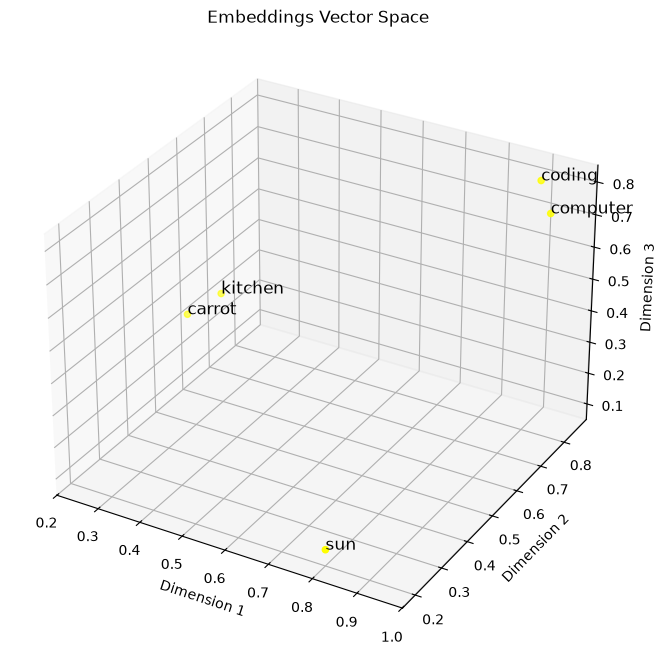

In [21]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')




# Plot points

ax.scatter(

    embeddings[:, 0],

    embeddings[:, 1],

    embeddings[:, 2],

    c = "yellow"

)
# Add Labels

for index, word in enumerate(words):

    ax.text(

        embeddings[index, 0],

        embeddings[index, 1],

        embeddings[index, 2],

        word,

        fontsize = 12

    )

    ax.set_title("Embeddings Vector Space")

ax.set_xlabel("Dimension 1")

ax.set_ylabel("Dimension 2")

ax.set_zlabel("Dimension 3")
plt.show()

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

In [1]:
import os
from dotenv import load_dotenv
from mistralai.client import Mistral

load_dotenv()
mistral = Mistral(api_key=os.environ['MISTRAL_API_KEY'])

In [2]:
documents = [
    "Cat", "Dog", "Bank", "School", "Engineer", "Salary"
]

response = mistral.embeddings.create(
    model = "mistral-embed",
    inputs = documents
)
response

EmbeddingResponse(id='02a214514a1e4f0a9d3895bc0552e12b', object='list', model='mistral-embed', usage=UsageInfo(prompt_tokens=20, completion_tokens=0, total_tokens=20, prompt_audio_seconds=None, request_count=None, prompt_tokens_details=None, completion_tokens_details=None, service_tier=None, prompt_token_details=None), data=[EmbeddingResponseData(object='embedding', embedding=[0.028045654296875, 0.0301513671875, 0.07330322265625, 0.0154266357421875, 0.019287109375, 0.0075836181640625, 0.0290985107421875, -0.01244354248046875, -0.0096893310546875, -0.003353118896484375, -0.036651611328125, 0.043487548828125, -0.037872314453125, -0.00885009765625, -0.026824951171875, 0.020416259765625, 0.0189361572265625, -0.0005068778991699219, 0.00666046142578125, 0.01003265380859375, -0.00907135009765625, 0.0005340576171875, -0.032073974609375, 0.0160369873046875, -0.03680419921875, 0.0250701904296875, -0.0189361572265625, -0.039093017578125, -0.0264739990234375, -0.0173492431640625, -0.026123046875, 

In [3]:
response.data

[EmbeddingResponseData(object='embedding', embedding=[0.028045654296875, 0.0301513671875, 0.07330322265625, 0.0154266357421875, 0.019287109375, 0.0075836181640625, 0.0290985107421875, -0.01244354248046875, -0.0096893310546875, -0.003353118896484375, -0.036651611328125, 0.043487548828125, -0.037872314453125, -0.00885009765625, -0.026824951171875, 0.020416259765625, 0.0189361572265625, -0.0005068778991699219, 0.00666046142578125, 0.01003265380859375, -0.00907135009765625, 0.0005340576171875, -0.032073974609375, 0.0160369873046875, -0.03680419921875, 0.0250701904296875, -0.0189361572265625, -0.039093017578125, -0.0264739990234375, -0.0173492431640625, -0.026123046875, -0.0269927978515625, 0.0175323486328125, 0.04803466796875, 0.040313720703125, -0.0043182373046875, 0.022796630859375, -0.023834228515625, 0.026824951171875, -0.00266265869140625, -0.038055419921875, -0.037689208984375, -0.03155517578125, 0.02471923828125, 0.0214691162109375, -0.0173492431640625, -0.00907135009765625, -0.0134

In [4]:
embeddings = [data.embedding for data in response.data]
embeddings

[[0.028045654296875,
  0.0301513671875,
  0.07330322265625,
  0.0154266357421875,
  0.019287109375,
  0.0075836181640625,
  0.0290985107421875,
  -0.01244354248046875,
  -0.0096893310546875,
  -0.003353118896484375,
  -0.036651611328125,
  0.043487548828125,
  -0.037872314453125,
  -0.00885009765625,
  -0.026824951171875,
  0.020416259765625,
  0.0189361572265625,
  -0.0005068778991699219,
  0.00666046142578125,
  0.01003265380859375,
  -0.00907135009765625,
  0.0005340576171875,
  -0.032073974609375,
  0.0160369873046875,
  -0.03680419921875,
  0.0250701904296875,
  -0.0189361572265625,
  -0.039093017578125,
  -0.0264739990234375,
  -0.0173492431640625,
  -0.026123046875,
  -0.0269927978515625,
  0.0175323486328125,
  0.04803466796875,
  0.040313720703125,
  -0.0043182373046875,
  0.022796630859375,
  -0.023834228515625,
  0.026824951171875,
  -0.00266265869140625,
  -0.038055419921875,
  -0.037689208984375,
  -0.03155517578125,
  0.02471923828125,
  0.0214691162109375,
  -0.017349243

In [7]:
similarity = cosine_similarity(embeddings)
similarity

array([[1.        , 0.81637625, 0.73649507, 0.73275199, 0.68790756,
        0.6951583 ],
       [0.81637625, 1.        , 0.73907211, 0.74347502, 0.68930917,
        0.69179075],
       [0.73649507, 0.73907211, 1.        , 0.78047785, 0.72623023,
        0.74241057],
       [0.73275199, 0.74347502, 0.78047785, 1.        , 0.73498707,
        0.74074002],
       [0.68790756, 0.68930917, 0.72623023, 0.73498707, 1.        ,
        0.71507494],
       [0.6951583 , 0.69179075, 0.74241057, 0.74074002, 0.71507494,
        1.        ]])